### 1. Importing Libraries and Config

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
from tqdm import tqdm
from config import DATA_DIR

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
AUDIO_ROOT = os.path.join(DATA_DIR, "train_audio")

taxonomy = pd.read_csv(os.path.join(DATA_DIR, "taxonomy.csv"))

### 2. Load Data

In [2]:
df = pd.read_csv(TRAIN_CSV)

print(df.shape)
df.head()

(35549, 15)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


### 3. File Index

In [3]:
records = []

for _, row in df.iterrows():
    path = os.path.join(AUDIO_ROOT, row["filename"])

    records.append({
        "primary_label": row["primary_label"],
        "filename": row["filename"],
        "audio_path": path
    })

eda_df = pd.DataFrame(records)

### 4. Missing and Corrupt File Checks

In [ ]:
statuses = []
durations = []

for path in tqdm(eda_df["audio_path"]):

    if not os.path.exists(path):
        statuses.append("missing")
        durations.append(np.nan)
        continue

    try:
        duration = librosa.get_duration(path=path)

        statuses.append("ok")
        durations.append(duration)

    except Exception:
        statuses.append("corrupt")
        durations.append(np.nan)

eda_df["status"] = statuses
eda_df["duration_sec"] = durations

100%|██████████| 35549/35549 [02:04<00:00, 286.45it/s]


### 5. Data Quality Summary

In [5]:
print(eda_df["status"].value_counts())

status
ok    35549
Name: count, dtype: int64


In [6]:
df["filename"].head(10)

0    1161364/iNat1216197.ogg
1    1161364/iNat1114648.ogg
2     1161364/iNat810195.ogg
3     1161364/iNat818781.ogg
4     1161364/iNat556514.ogg
5     1161364/iNat868369.ogg
6     1161364/iNat842139.ogg
7     1161364/iNat840159.ogg
8    1161364/iNat1264238.ogg
9     1161364/iNat869958.ogg
Name: filename, dtype: str

In [7]:
eda_df["audio_path"].head(10).tolist()

['/mnt/disks/data/birdclef/train_audio/1161364/iNat1216197.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat1114648.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat810195.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat818781.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat556514.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat868369.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat842139.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat840159.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat1264238.ogg',
 '/mnt/disks/data/birdclef/train_audio/1161364/iNat869958.ogg']

In [8]:
eda_df[eda_df["status"] != "ok"].head()

,primary_label,filename,audio_path,status,duration_sec


In [9]:
eda_df[eda_df["status"] != "ok"]["primary_label"].value_counts()

Series([], Name: count, dtype: int64)

### 6. Species Distribution Bar Chart

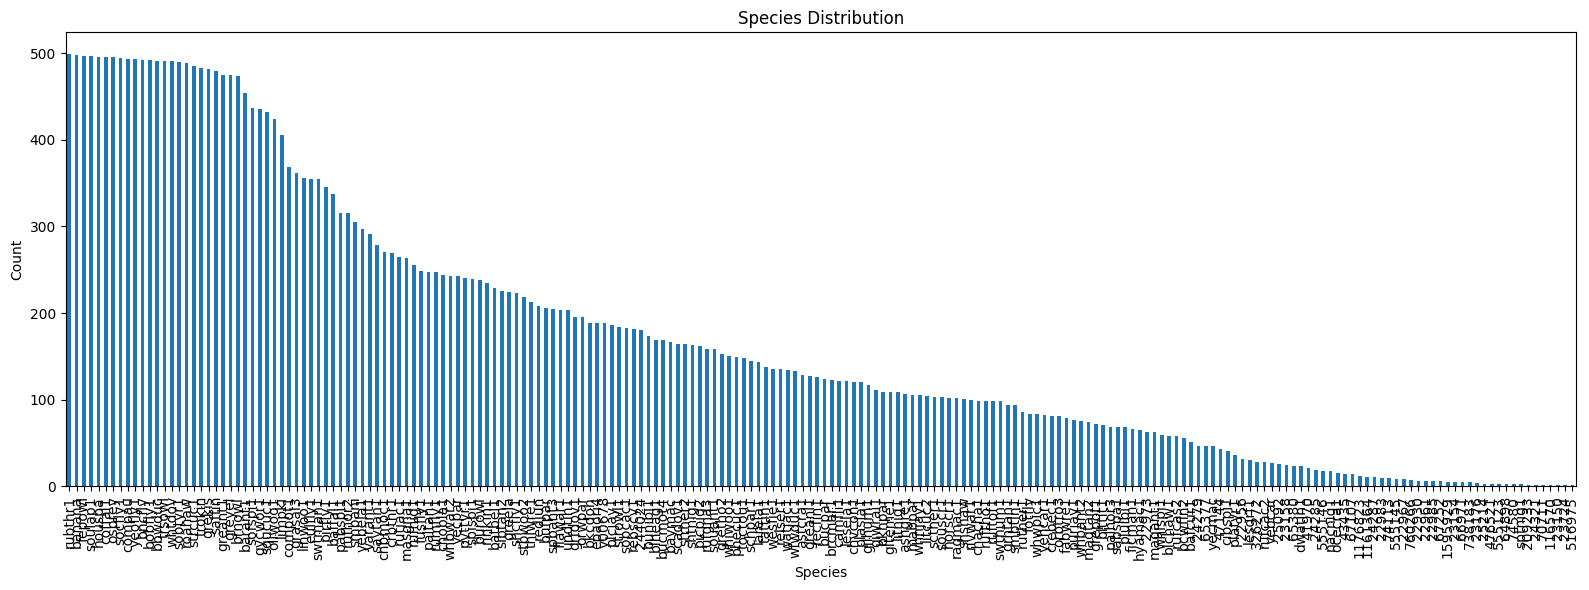

In [10]:
species_counts = eda_df["primary_label"].value_counts()

plt.figure(figsize=(16,6))
species_counts.plot(kind="bar")

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### 7. Ranked Imbalance Table

In [11]:
imbalance_df = pd.DataFrame({
    "species": species_counts.index,
    "count": species_counts.values
})

imbalance_df["rank"] = range(1, len(imbalance_df)+1)

display(imbalance_df.head(10))
display(imbalance_df.tail(10))

,species,count,rank
0,rubthr1,499,1
1,banana,498,2
2,fepowl,497,3
3,soulap1,497,4
4,houspa,496,5
5,coffal1,495,6
6,osprey,495,7
7,socfly1,494,8
8,compau,493,9
9,yeofly1,493,10


,species,count,rank
196,64898,3,197
197,74580,3,198
198,sptnig1,3,199
199,209233,2,200
200,24321,2,201
201,70711,2,202
202,116570,1,203
203,23150,1,204
204,23724,1,205
205,516975,1,206


In [12]:
most_common_species = species_counts.idxmax()
most_common_count = species_counts.max()

print(most_common_species, most_common_count)

rubthr1 499


In [13]:
least_common_species = species_counts[
    species_counts == species_counts.min()
]

least_common_species

primary_label
116570    1
23150     1
23724     1
516975    1
Name: count, dtype: int64

In [14]:
imbalance_ratio = species_counts.max() / species_counts.min()

print(imbalance_ratio)

499.0


In [15]:
print(species_counts.describe())

count    206.000000
mean     172.567961
std      155.371004
min        1.000000
25%       47.250000
50%      125.000000
75%      243.750000
max      499.000000
Name: count, dtype: float64


### 8. Taxonomy Coverage vs Observed Training Labels

In [16]:
taxonomy_species = set(taxonomy["primary_label"])

In [17]:
import ast

secondary_species = set()

for labels in df["secondary_labels"].fillna("[]"):
    try:
        parsed = ast.literal_eval(labels)

        for s in parsed:
            secondary_species.add(s)

    except:
        pass

In [18]:
primary_species = set(df["primary_label"])

all_seen = primary_species.union(secondary_species)

print("taxonomy:", len(taxonomy_species))
print("primary:", len(primary_species))
print("secondary:", len(secondary_species))
print("all seen:", len(all_seen))

print("taxonomy-only species:")
print(taxonomy_species - all_seen)

taxonomy: 234
primary: 206
secondary: 161
all seen: 206
taxonomy-only species:
{'47158son21', '47158son12', '47158son20', '47158son14', '47158son18', '47158son15', '47158son05', '47158son10', '47158son04', '517063', '47158son07', '47158son01', '47158son09', '47158son02', '47158son23', '47158son25', '47158son03', '1491113', '47158son22', '47158son24', '47158son19', '47158son13', '47158son11', '47158son16', '25073', '47158son17', '47158son06', '47158son08'}


### 9. Duration Histogram

In [19]:
valid_df = eda_df[eda_df["status"] == "ok"]

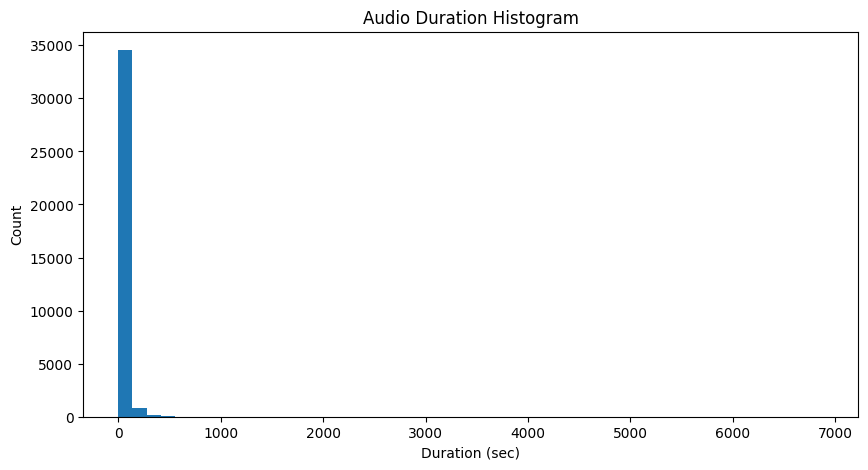

In [20]:
plt.figure(figsize=(10,5))

plt.hist(valid_df["duration_sec"], bins=50)

plt.title("Audio Duration Histogram")
plt.xlabel("Duration (sec)")
plt.ylabel("Count")

plt.show()

### 10. Duration Summary Stats

In [21]:
dur = valid_df["duration_sec"]

print("Min:", dur.min())
print("Median:", dur.median())
print("Mean:", dur.mean())
print("P95:", dur.quantile(0.95))
print("Max:", dur.max())

Min: 0.008
Median: 21.0
Mean: 34.88259529012771
P95: 103.58059999999999
Max: 6881.097


## Key Findings

### Class Imbalance
- Most common species: rubthr1	(499 samples)
- Least common species: multiple classes with only 1 sample each (`116570`, `23150`, `23724`, `516975`)
- Imbalance ratio: `499:1`

The dataset exhibits a strong long-tail class distribution, with several species represented by only 1–3 samples while the most common species contain nearly 500 recordings. Minority-class learning may therefore be difficult without balancing strategies.

### Data Quality

- Missing files: 
- Corrupt/unreadable files: 
- Successfully validated audio files: 

Note
- Taxonomy defines: 234 possible species
- Training data includes: 206 species
- Missing from training: 28 species (no recordings available)
- All available audio files: valid (status = "ok")

### Duration Analysis
- Median duration: ...
- Long-tail outliers detected: yes/no

### Recommendations
- Weighted sampling recommended
- Consider focal loss
- Use fixed 5-second clips